# Validating encoded bosonic displacement circuits

This notebook compares a native `bosonic_qiskit` displacement with the qubit circuits generated from the truncated position quadrature operator.

The project circuit implements

$$
U(t) = \exp(-i\,\theta\,t\,q), \qquad q = \frac{a + a^\dagger}{\sqrt{2}}.
$$

In the usual displacement convention

$$
D(\alpha) = \exp(\alpha a^\dagger - \alpha^* a),
$$

this corresponds to the native displacement parameter

$$
\alpha = -i\,\theta\,t / \sqrt{2}.
$$

The Wigner plots are a visual check. 

## 1. Imports and project setup

This cell finds the repository root from the current notebook location, then adds both this project and the vendored `bosonic-qiskit` package to `sys.path`.

In [3]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "bosonic-qiskit" / "src").is_dir():
            return candidate
    raise RuntimeError("Could not find the bosonic_gatecounts project root.")


project_root = find_project_root(Path.cwd().resolve())
bosonic_qiskit_src = project_root / "bosonic-qiskit" / "src"

for path in (project_root, bosonic_qiskit_src):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print(f"Project root: {project_root}")

Project root: /Users/hollyelizabethmitchell/Documents/code/bosonic_gatecounts


In [4]:
import numpy as np
import pandas as pd
from qiskit.quantum_info import Statevector

import bosonic_qiskit

from src.bosonic_validation.bosonic_test_op import (
    decode_unary_state,
    gray_to_binary_circuit,
    position_operator_test_circuit
)

## 2. Parameters

Change these values to explore different cutoffs, encodings, evolution times, and Trotter depths. Keep `d` as a power of two for the Wigner plots, because `bosonic_qiskit` represents one qumode with a binary qubit register.

In [5]:
d = 16

theta = 1.0
time = 1.0
trotter_steps = 20
optimize = True

wigner_axes_min = -4
wigner_axes_max = 4
wigner_axes_steps = 120

if d <= 0 or d & (d - 1):
    raise ValueError("Choose d as a positive power of two for this notebook.")

num_binary_qubits = int(np.log2(d))
alpha_reference = -1j * theta * time / np.sqrt(2)

print(f"Binary qubits for cutoff d={d}: {num_binary_qubits}")
print(f"Native displacement alpha for exp(-i theta*time*q): {alpha_reference}")

Binary qubits for cutoff d=16: 4
Native displacement alpha for exp(-i theta*time*q): -0.7071067811865475j


## 3. Small notebook helpers

These wrappers keep the validation sections short. The implementation logic still lives in `src/bosonic_validation/bosonic_test_op.py`.

In [6]:
def make_vacuum_circuit(cutoff: int):
    num_qubits = int(np.log2(cutoff))
    qmr = bosonic_qiskit.QumodeRegister(
        num_qumodes=1,
        num_qubits_per_qumode=num_qubits,
    )
    circuit = bosonic_qiskit.CVCircuit(qmr)
    circuit.cv_initialize(0, qmr[0])
    return circuit, qmr


def make_empty_plot_circuit(cutoff: int):
    num_qubits = int(np.log2(cutoff))
    qmr = bosonic_qiskit.QumodeRegister(
        num_qumodes=1,
        num_qubits_per_qumode=num_qubits,
    )
    return bosonic_qiskit.CVCircuit(qmr), qmr


def simulate_cv_state(circuit):
    state, _, _ = bosonic_qiskit.util.simulate(
        circuit,
        return_fockcounts=False,
    )
    if state is None:
        raise RuntimeError("Simulation did not return a statevector.")
    return state


def plot_wigner(circuit, state, title: str):
    print(title)
    bosonic_qiskit.wigner.plot_wigner(
        circuit,
        state,
        draw_grid=False,
        axes_min=wigner_axes_min,
        axes_max=wigner_axes_max,
        axes_steps=wigner_axes_steps,
    )


def build_encoded_state(encoding: str):
    custom_circuit = position_operator_test_circuit(
        d=d,
        encoding=encoding,
        theta=theta,
        time=time,
        trotter_steps=trotter_steps,
        optimize=optimize,
    )

    circuit, qmr = make_vacuum_circuit(d)
    circuit.compose(custom_circuit, qubits=qmr[0], inplace=True)

    if encoding == "gray":
        decoder = gray_to_binary_circuit(custom_circuit.num_qubits)
        circuit.compose(decoder, qubits=qmr[0], inplace=True)

    return circuit, simulate_cv_state(circuit), custom_circuit

## 4. Native bosonic-qiskit reference

This is the target state generated by applying the equivalent native displacement to the vacuum.

Native bosonic_qiskit reference


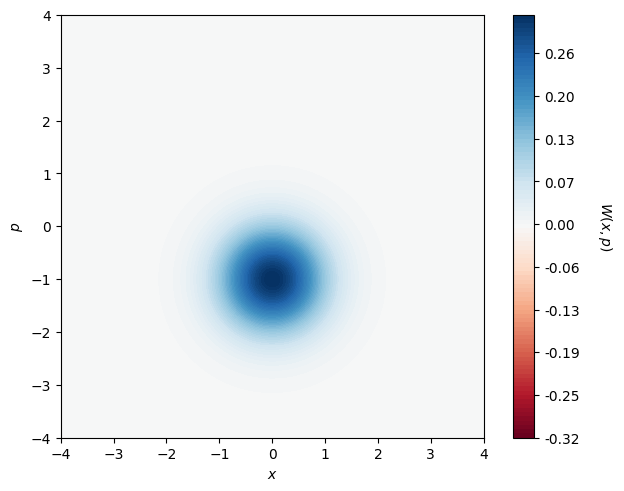

In [7]:
reference_circuit, reference_qmr = make_vacuum_circuit(d)
reference_circuit.cv_d(alpha_reference, reference_qmr[0])
reference_state = simulate_cv_state(reference_circuit)

plot_wigner(reference_circuit, reference_state, "Native bosonic_qiskit reference")

## 5. Standard binary encoded circuit

Standard binary already uses the same basis ordering expected by the Wigner plotting routine.

In [1]:
sb_circuit, sb_state, sb_custom_circuit = build_encoded_state("sb")

plot_wigner(sb_circuit, sb_state, "Standard binary encoded circuit")
# print(sb_custom_circuit.draw(fold=-1))

NameError: name 'build_encoded_state' is not defined

## 6. Gray encoded circuit

The Gray-encoded circuit is decoded back to standard binary before plotting or comparing with the native reference.

Gray encoded circuit decoded to standard binary


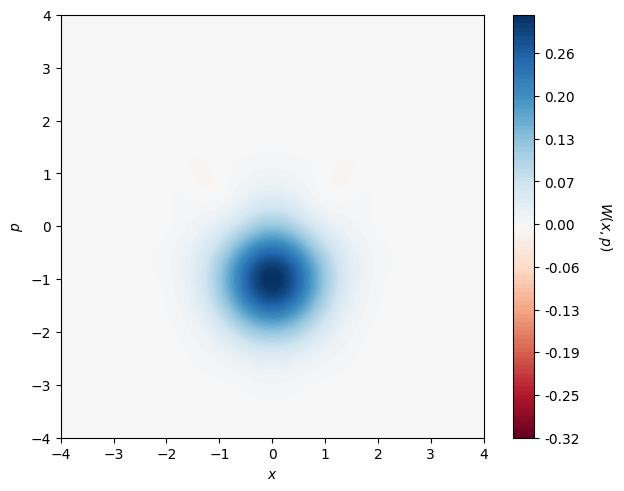

global phase: π
        ┌───┐    ┌─────────────┐                                                                                                                                                                                                                                                                                                                                                          ┌───┐                                                                             ┌───────────┐  ┌─────┐┌───┐   ┌─────┐        ┌─────┐     ┌───┐┌─────┐┌────────────┐┌───────────┐   ┌─────┐     ┌───┐ ┌─────┐┌────────┐  ┌─────┐      ┌───┐   ┌─────┐┌────────────┐                                                         ┌──────────────┐┌─────┐┌───┐┌─────┐  ┌────────┐  ┌─────┐┌───┐┌─────┐┌────────────┐┌───────────┐     ┌─────┐     ┌───┐┌─────┐┌────────┐┌─────┐    ┌───┐     ┌─────┐┌────────────┐                                                                                                   ┌─────────────

In [9]:
gray_circuit, gray_state, gray_custom_circuit = build_encoded_state("gray")

plot_wigner(gray_circuit, gray_state, "Gray encoded circuit decoded to standard binary")
print(gray_custom_circuit.draw(fold=-1))

## 7. Unary encoded circuit

Unary uses `d` qubits instead of `log2(d)` qubits, so it cannot be composed directly into a `bosonic_qiskit` qumode register. Instead, the amplitudes in the one-hot unary code space are extracted into a length-`d` Fock-basis statevector for plotting and comparison.

Unary encoded circuit decoded to Fock basis


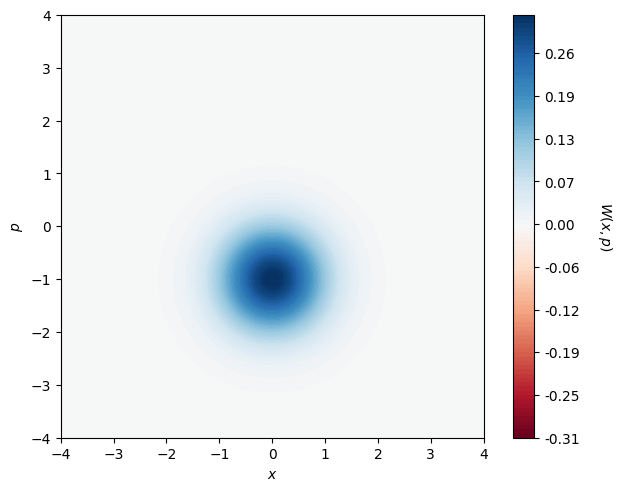

In [11]:
unary_custom_circuit = position_operator_test_circuit(
    d=d,
    encoding="unary",
    theta=theta,
    time=time,
    trotter_steps=trotter_steps,
    optimize=optimize,
)

unary_state = decode_unary_state(unary_custom_circuit, d=d)

unary_plot_circuit, _ = make_empty_plot_circuit(d)
plot_wigner(unary_plot_circuit, unary_state, "Unary encoded circuit decoded to Fock basis")